In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
# ✅ Classes
SEASON_CLASSES = ['Spring', 'Summer', 'Autumn', 'Winter']

# ✅ Dataset
class PersonalColorDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None):
        self.data = pd.read_csv(csv_path)
        self.image_root = image_root
        self.transform = transform
        self.label_map = {season: idx for idx, season in enumerate(SEASON_CLASSES)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.image_root, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[row['season']]

        if self.transform:
            image = self.transform(image)

        return image, label

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [11]:
# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Dataloaders
train_dataset = PersonalColorDataset(csv_path='dataset_fake_parsing/train.csv',image_root='dataset_fake_parsing',transform=train_transform)
val_dataset = PersonalColorDataset(csv_path='dataset_fake_parsing/val.csv', image_root='dataset_fake_parsing', transform=val_transform)
test_dataset = PersonalColorDataset(csv_path='dataset_fake_parsing/test.csv',image_root='dataset_fake_parsing',transform=val_transform)

# ✅ Class Weights
df = pd.read_csv('dataset_fake_parsing/train.csv')
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df['season']), y=df['season'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Calculate weights for each sample
label_to_idx = {label: idx for idx, label in enumerate(SEASON_CLASSES)}
labels = df['season'].map(label_to_idx)
class_sample_counts = labels.value_counts().sort_index().values
class_weights = 1. / class_sample_counts
sample_weights = [class_weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Replace train_loader
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

🔍 Class Distribution in Training Set:
season
Spring    240
Summer    240
Autumn    239
Winter    204
Name: count, dtype: int64


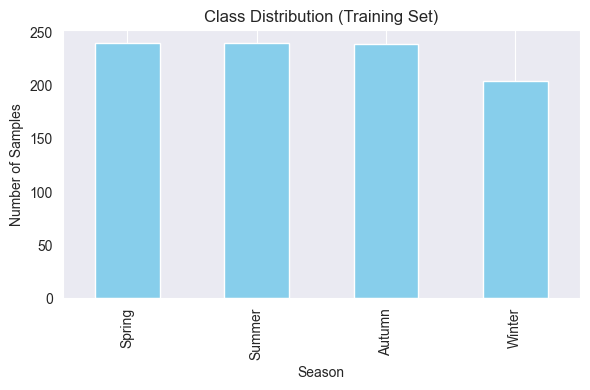

In [12]:
# Count class distribution
class_counts = df['season'].value_counts().reindex(SEASON_CLASSES)

# Print counts
print("🔍 Class Distribution in Training Set:")
print(class_counts)

# Plot as bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color='skyblue')
plt.title("Class Distribution (Training Set)")
plt.xlabel("Season")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [13]:
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
weights = EfficientNet_B2_Weights.DEFAULT
model = efficientnet_b2(weights=weights)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 4)
)

model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_loss = None

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
            return False
        elif val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            return self.counter >= self.patience

def train_model(model, train_loader, val_loader, epochs):
    early_stopper = EarlyStopping(patience=3, min_delta=0.0)
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }
    best_val_loss = float("inf")
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        torch.cuda.empty_cache()

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        print(f"Learning Rate: {current_lr:.6f}")

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{epoch+1}/{epochs}] Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "model/efficientnet_b2_best.pth")

        # Early stopping
        if early_stopper(avg_val_loss):
            print("Early stopping triggered.")
            break

    return history

history = train_model(model, train_loader, val_loader, epochs=30)

import pickle
with open("history/efficientnet_b2_best_history.pkl", "wb") as f:
    pickle.dump(history, f)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\senghuy/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:08<00:00, 4.43MB/s]
Epoch 1/30: 100%|██████████| 29/29 [00:15<00:00,  1.92it/s]


Learning Rate: 0.000199
[1/30] Train Loss: 1.1377, Train Acc: 50.38%, Val Acc: 62.93%, Val Loss: 0.8966


Epoch 2/30: 100%|██████████| 29/29 [00:14<00:00,  1.95it/s]


Learning Rate: 0.000198
[2/30] Train Loss: 0.7503, Train Acc: 74.65%, Val Acc: 72.41%, Val Loss: 0.7287


...

Learning Rate: 0.000167
[8/30] Train Loss: 0.4678, Train Acc: 88.19%, Val Acc: 68.97%, Val Loss: 0.7884
EarlyStopping counter: 1/3


Epoch 9/30: 100%|██████████| 29/29 [00:17<00:00,  1.67it/s]


Learning Rate: 0.000159
[9/30] Train Loss: 0.4558, Train Acc: 88.19%, Val Acc: 71.55%, Val Loss: 0.7671
EarlyStopping counter: 2/3


Epoch 10/30: 100%|██████████| 29/29 [00:15<00:00,  1.92it/s]


Learning Rate: 0.000150
[10/30] Train Loss: 0.3844, Train Acc: 92.42%, Val Acc: 71.55%, Val Loss: 0.8104
EarlyStopping counter: 3/3
Early stopping triggered.


In [16]:

# ✅ Load EfficientNet-B1 structure with default weights
weights = EfficientNet_B2_Weights.DEFAULT
loaded_model = efficientnet_b2(weights=weights)

# ✅ Replace classifier head to match number of classes
loaded_model.classifier[1] = nn.Linear(loaded_model.classifier[1].in_features, 4)

# ✅ Load trained weights
loaded_model.load_state_dict(torch.load("model/efficientnet_b2_best.pth"))

# ✅ Move to device and set to eval mode
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("✅ Best EfficientNet-B1 model loaded successfully")


✅ Best EfficientNet-B1 model loaded successfully


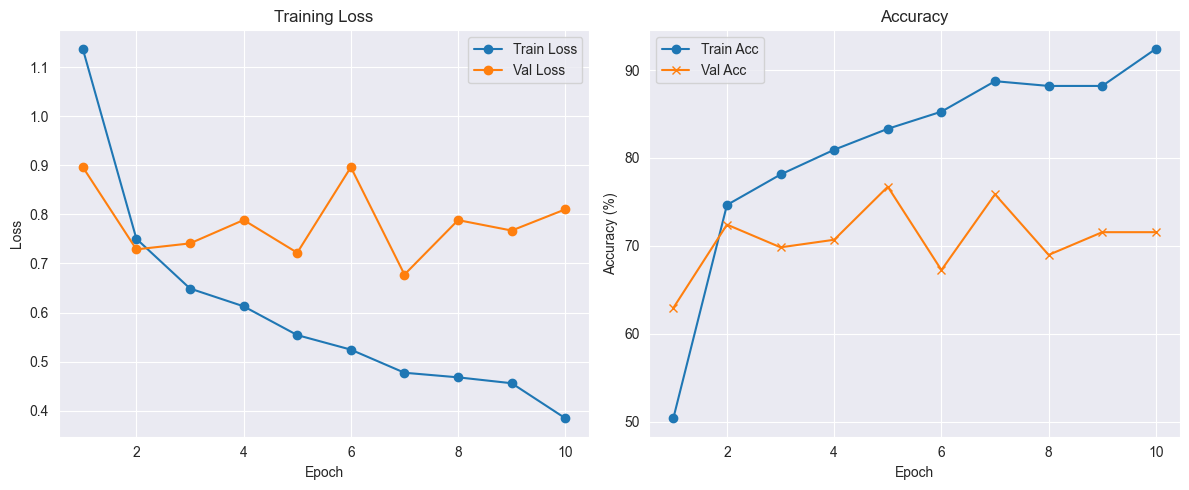

In [17]:
with open("history/efficientnet_b2_best_history.pkl", "rb") as f:
    history = pickle.load(f)


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label='Train Loss', marker='o')
    plt.plot(epochs, history["val_loss"], label='Val Loss', marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label='Train Acc', marker='o')
    plt.plot(epochs, history["val_acc"], label='Val Acc', marker='x')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

Test Accuracy: 81.03%

Classification Report:
              precision    recall  f1-score   support

      Spring       0.91      0.70      0.79        30
      Summer       0.96      0.77      0.85        30
      Autumn       0.71      0.90      0.79        30
      Winter       0.74      0.88      0.81        26

    accuracy                           0.81       116
   macro avg       0.83      0.81      0.81       116
weighted avg       0.83      0.81      0.81       116



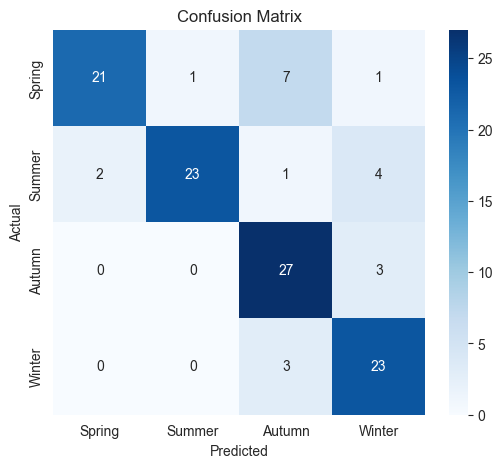

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    total = len(all_labels)
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=SEASON_CLASSES))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SEASON_CLASSES, yticklabels=SEASON_CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(loaded_model, test_loader)

In [20]:
import torch
from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from PIL import Image

# ✅ Constants
SEASON_CLASSES = ['Spring', 'Summer', 'Autumn', 'Winter']
MODEL_PATH = "model/efficientnet_b2_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Load model
weights = EfficientNet_B2_Weights.DEFAULT
model = efficientnet_b2(weights=weights)
in_features = model.classifier[1].in_features
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(0.2),
    torch.nn.Linear(in_features, 4)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [36]:
import sys
sys.path.append('./face_parsing')

import torch
import numpy as np
import cv2
from PIL import Image
from model import BiSeNet
from torchvision import transforms
from torchvision.models import efficientnet_b2
import os

# === Constants
SEASON_CLASSES = ['Spring', 'Summer', 'Autumn', 'Winter']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Load face parsing model
def load_face_parser():
    net = BiSeNet(n_classes=19).to(DEVICE)
    net.load_state_dict(torch.load("model/79999_iter.pth"))
    net.eval()
    return net

face_parser = load_face_parser()

# === Load EfficientNet-B2 model
def load_color_model():
    model = efficientnet_b2(weights=None)
    model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 4)
    model.load_state_dict(torch.load("model/efficientnet_b2_best.pth", map_location=DEVICE))
    model.eval().to(DEVICE)
    return model

color_model = load_color_model()

# === Inference transform (same as val_transform)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# === Predict from real image
def predict_season_from_real_image(image_path):
    img = Image.open(image_path).convert("RGB")
    image = img.resize((512, 512), Image.BILINEAR)

    # === Step 1: Parse face
    to_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    img_tensor = to_tensor(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = face_parser(img_tensor)[0]
        parsing = out.squeeze(0).cpu().numpy().argmax(0)

    # === Step 2: Extract skin (label=1)
    skin_mask = (parsing == 1).astype(np.uint8) * 255
    skin_mask = cv2.resize(skin_mask, image.size, interpolation=cv2.INTER_NEAREST)
    img_np = np.array(image)
    masked_image = np.where(skin_mask[..., None] == 255, img_np, 255).astype(np.uint8)

    # === Step 3: Resize, normalize and predict
    skin_only = Image.fromarray(masked_image).resize((224, 224))
    input_tensor = preprocess(skin_only).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = color_model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
        predicted_season = SEASON_CLASSES[pred_idx]

    return predicted_season, masked_image

Predicted Personal Color Type: Winter


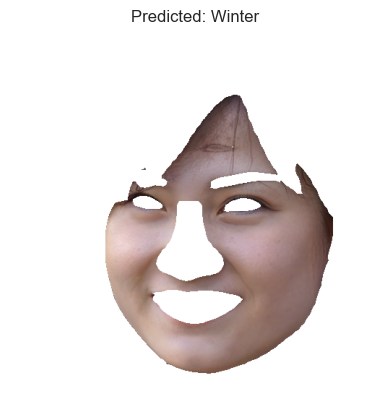

In [39]:
image_path = "dataset_fake/Winter/seed0036.png"
season, skin_image = predict_season_from_real_image(image_path)
print(f"Predicted Personal Color Type: {season}")

plt.imshow(skin_image)
plt.title(f"Predicted: {season}")
plt.axis("off")
plt.show()